In [1]:
"""
Created By    : Jared W. Marquis
Creation Date : 01 August 2022
Course        : ATSC 528 - Atmospheric Data Analysis
Assignment    : #01 - Function Fitting

Purpose:
Script to take sparse upper air observations and analyze them on a
polar stereographic map projection using function fitting.
[PUT MORE INFORMATION HERE - I.E., WHAT SPECIFIC THING IS BEING DONE]

"""
__author__    = "Jared W. Marquis"
__contact__   = "jared.marquis@und.edu"

Student Name: Austin Portner

In [2]:
### Import Required Modules (shouldn't need to change) ###
import numpy as np                 #numpy for math
import matplotlib.pyplot as plt    #matplotlib for plotting
import cartopy.crs as ccrs         #cartopy for plotting on map
import cartopy.feature as cfeature #cartopy basic shapefiles

In [3]:
### Read in observations ###

#Note path and file are for my computer only
path = 'C:/Users/austi/Desktop/AtSc_Masters_Classes/AtSc_528/Function_Fitting/'
file = 'RAOBs_201903131200.txt'
#path+file #Sanity check to ensure I have correct file path

In [4]:
### Set up analysis map with a 21x27 rectangular grid of points ###
lats, lons, hgts = [], [], []

with open(file, 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) >=4:
            try:
                lat = float(parts[1])
                lon = float(parts[2])
                hgt = float(parts[3])
                # append valid observation data
                if not np.isnan(hgt):
                    lats.append(lat)
                    lons.append(lon)
                    hgts.append(hgt)
            except ValueError:
                continue

#Conversion to np arrays
obs_lat = np.array(lats)
obs_lon = np.array(lons)
obs_hgt = np.array(hgts)

# Now to setip 21x27 analysis grid
y, x = 27, 21
dx, dy = 1.27, 1.27 #in cm
x0, y0 = 25.0, -15.5 #in cm

# Now to generate 1D vectors and 2D meshgrid
grid_x_1d = x0 + np.arange(x) * dx
grid_y_1d = y0 + np.arange(y) * dy

grid_x_map, grid_y_map = np.meshgrid(grid_x_1d, grid_y_1d, indexing = 'ij')

In [5]:
### convert obs lat/long to x,y (may want to plot on your analysis grid to verify)###
# Doing pure math way to provide projection parameters
lambda_0 = -100.0
phi_0 = 60.0
rho = 6371229.0 
m = 1 / 15000000
R = rho * 100.0 * m

# Angles from lat/lon to radians
lat_rad = np.radians(obs_lat)
lon_rad = np.radians(obs_lon)
lambda_0_rad = np.radians(lambda_0)
phi_0_rad = np.radians(phi_0)

#conversion to cartesian coordinates in cm
sigma_obs = (1.0 + np.sin(phi_0_rad)) / (1.0 + np.sin(lat_rad))
obs_x = R * sigma_obs * np.cos(lat_rad) * np.cos(lon_rad - lambda_0_rad)
obs_y = R * sigma_obs * np.cos(lat_rad) * np.sin(lon_rad - lambda_0_rad)

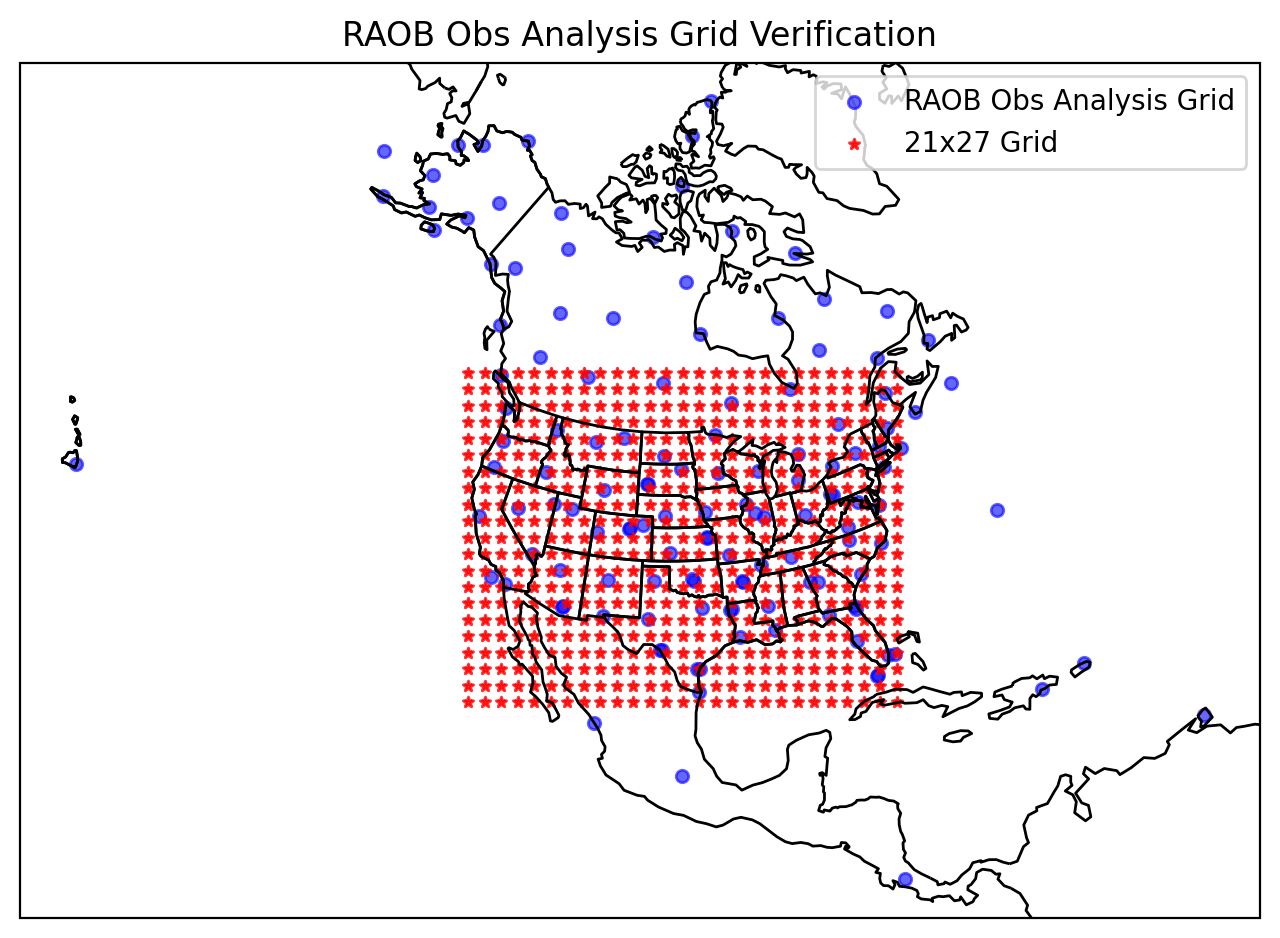

In [6]:
#Plt for sanity check
globe = ccrs.Globe(ellipse=None, semimajor_axis = rho, semiminor_axis = rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax = fig.add_subplot(111,projection=proj)

#21x27 gridpoints
ax.scatter(obs_y / m / 100, -obs_x / m / 100, color = 'blue', s = 20, alpha = 0.6, label = 'RAOB Obs Analysis Grid', transform = proj)
ax.scatter(grid_y_map / m / 100, -grid_x_map / m / 100, color = 'red', s = 15, marker = '*', alpha = 0.8, label = '21x27 Grid', transform = proj)
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.COASTLINE)

ax.set_xlabel('X-Coordinate (cm)')
ax.set_ylabel('Y-Coordinate (cm)')
ax.set_title('RAOB Obs Analysis Grid Verification')
ax.legend(loc = 'upper right')
ax.grid(True, linestyle = '--', alpha = 0.5)
ax.set_aspect('equal')
plt.show()

In [14]:
### Perform 500mb geopotential height analyses using a second order 2-d polynomial with two ###
### radii of influence (10cm & 20cm) ###
def obj_analysis_2nd_order_poly2d(obs_x, obs_y, obs_hgt, grid_x_map, grid_y_map, R_inf):
    """
    Performs a local objective analysis using Cressman distance weighting.
    """
    map_x_dim, map_y_dim = grid_x_map.shape # gets dimensions for polynomial
    grid_hgts_analysis = np.full((map_x_dim, map_y_dim), np.nan)
    grid_obs_counts = np.zeros((map_x_dim, map_y_dim), dtype = int)
    
    for i in range(map_x_dim):
        for j in range(map_y_dim):
            xg = grid_x_map[i, j]
            yg = grid_y_map[i, j]
            
            # relative distance from cuurent grid pts to all obs
            dx_dist = obs_x - xg
            dy_dist = obs_y - yg
            dist = np.sqrt(dx_dist**2 + dy_dist**2)
            
            # Obs filter within roi
            mask = dist <= R_inf
            n_obs = np.sum(mask)
            grid_obs_counts[i, j] = n_obs
            
            # 2D 2nd order poly (note: this requires min 6 pts to solve)
            if n_obs >= 6:
                dx_sub = dx_dist[mask]
                dy_sub = dy_dist[mask]
                hgt_sub = obs_hgt[mask]
                d_sub = dist[mask]
                
                # Cressman dist function
                weights = (R_inf**2 - d_sub**2) / (R_inf**2 + d_sub**2)
                
                # Matrix A (Note: formatting of code is for my understanding of what I wrote)
                A = np.column_stack([np.ones_like(dx_sub),
                    dx_sub, dy_sub,
                    dx_sub**2,
                    dy_sub**2,
                    dx_sub * dy_sub])
                
                # Weighted least squares needs the square root of weights performed
                w_sqrt = np.sqrt(weights)
                A_w = A * w_sqrt[:, None]
                b_w = hgt_sub * w_sqrt
                
                # Solving for c0, c1, c2, c3, c4, and c5 in the poly
                coeffs, _, _, _ = np.linalg.lstsq(A_w, b_w, rcond = None)
                
                # Value evaluated at grid center (dx = 0, dy = 0) is c0
                grid_hgts_analysis[i, j] = coeffs[0]

    return grid_hgts_analysis, grid_obs_counts

# Analysis for 10cm and 20cm
analysis_10cm, counts_10cm = obj_analysis_2nd_order_poly2d(obs_x, obs_y, obs_hgt, grid_x_map, grid_y_map, R_inf = 10.0)
analysis_20cm, counts_20cm = obj_analysis_2nd_order_poly2d(obs_x, obs_y, obs_hgt, grid_x_map, grid_y_map, R_inf = 20.0)

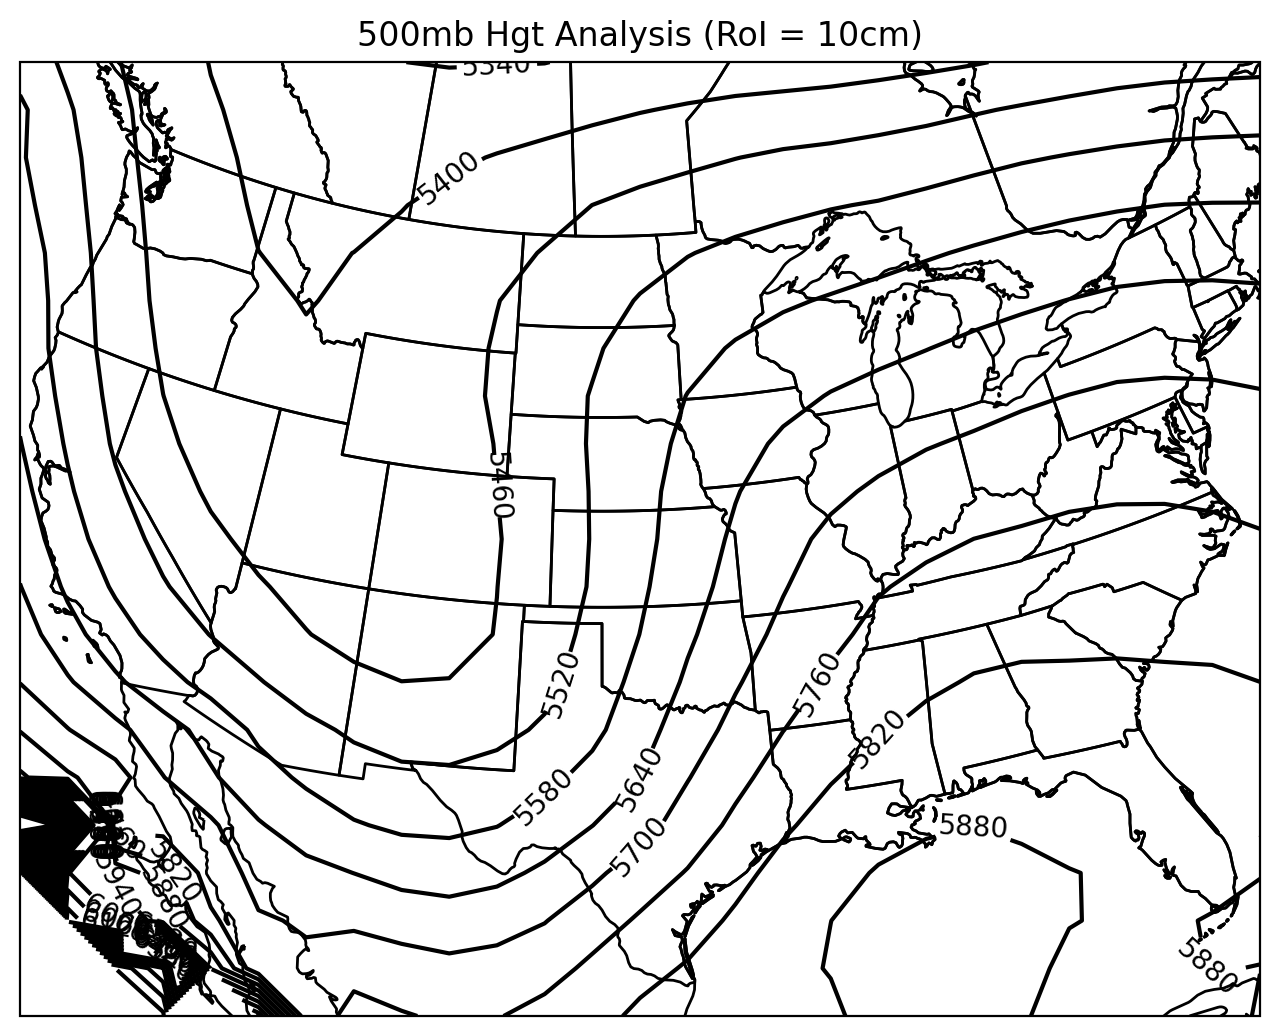

In [8]:
### Plot 500mb analyses over a map (10cm analysis) ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)

ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot analysis (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,analysis_10cm,colors='k',levels=np.arange(0,8000,60),transform=proj)
plt.clabel(cs1,levels=np.arange(0,8000,60))
ax1.set_title('500mb Hgt Analysis (RoI = 10cm)')
plt.savefig('500mb_hgt_10cm.png', dpi = 300, bbox_inches = 'tight')

plt.show()

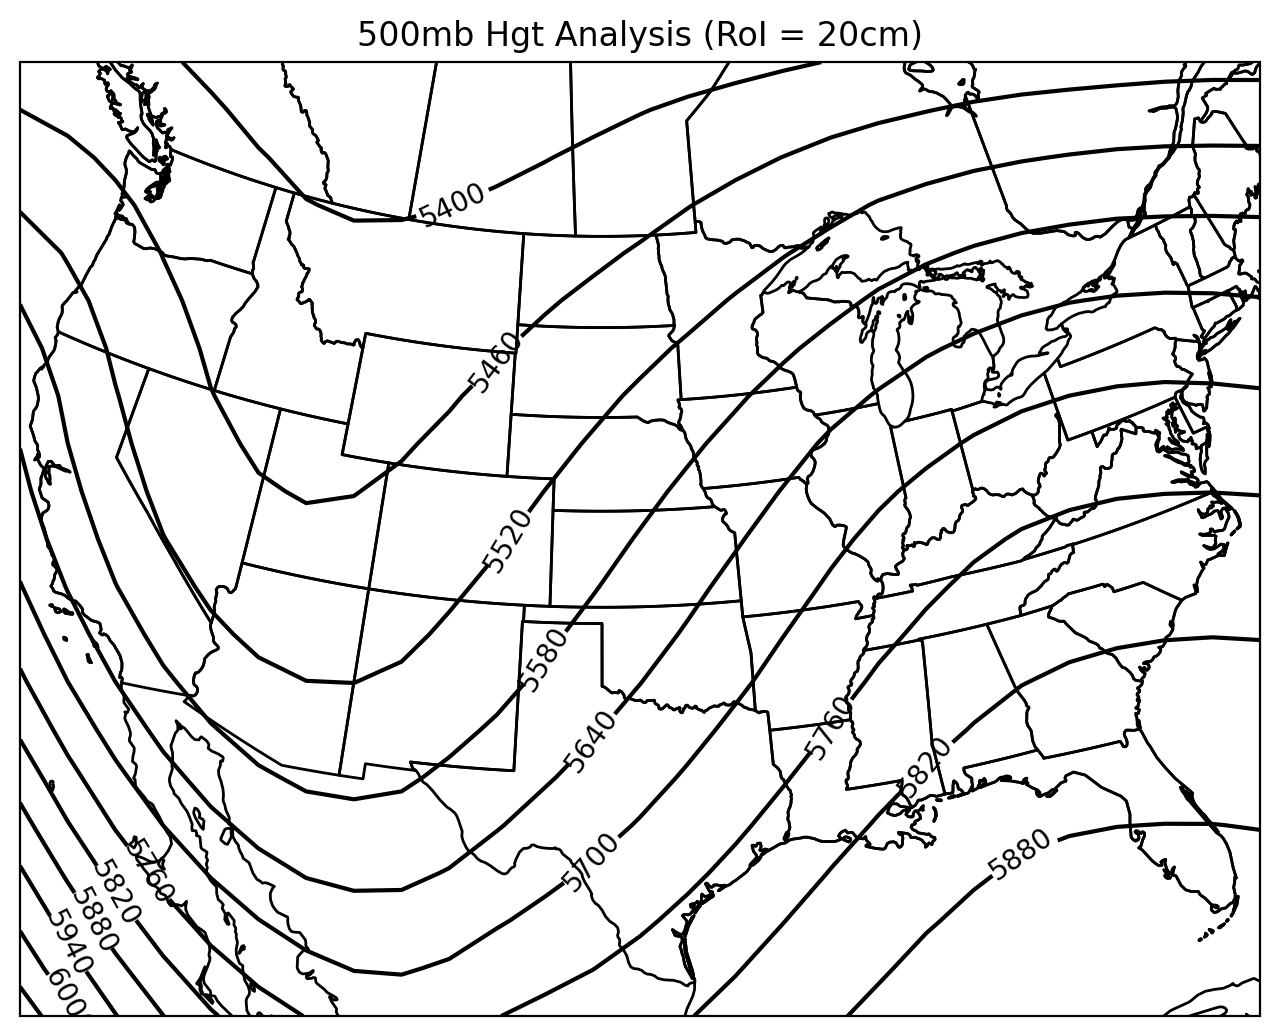

In [9]:
### Plot 500mb analyses over a map (20cm analysis) ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)

ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot analysis (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,analysis_20cm,colors='k',levels=np.arange(0,8000,60),transform=proj)
plt.clabel(cs1,levels=np.arange(0,8000,60))
ax1.set_title('500mb Hgt Analysis (RoI = 20cm)')
plt.savefig('500mb_hgt_20cm.png', dpi = 300, bbox_inches = 'tight')

plt.show()

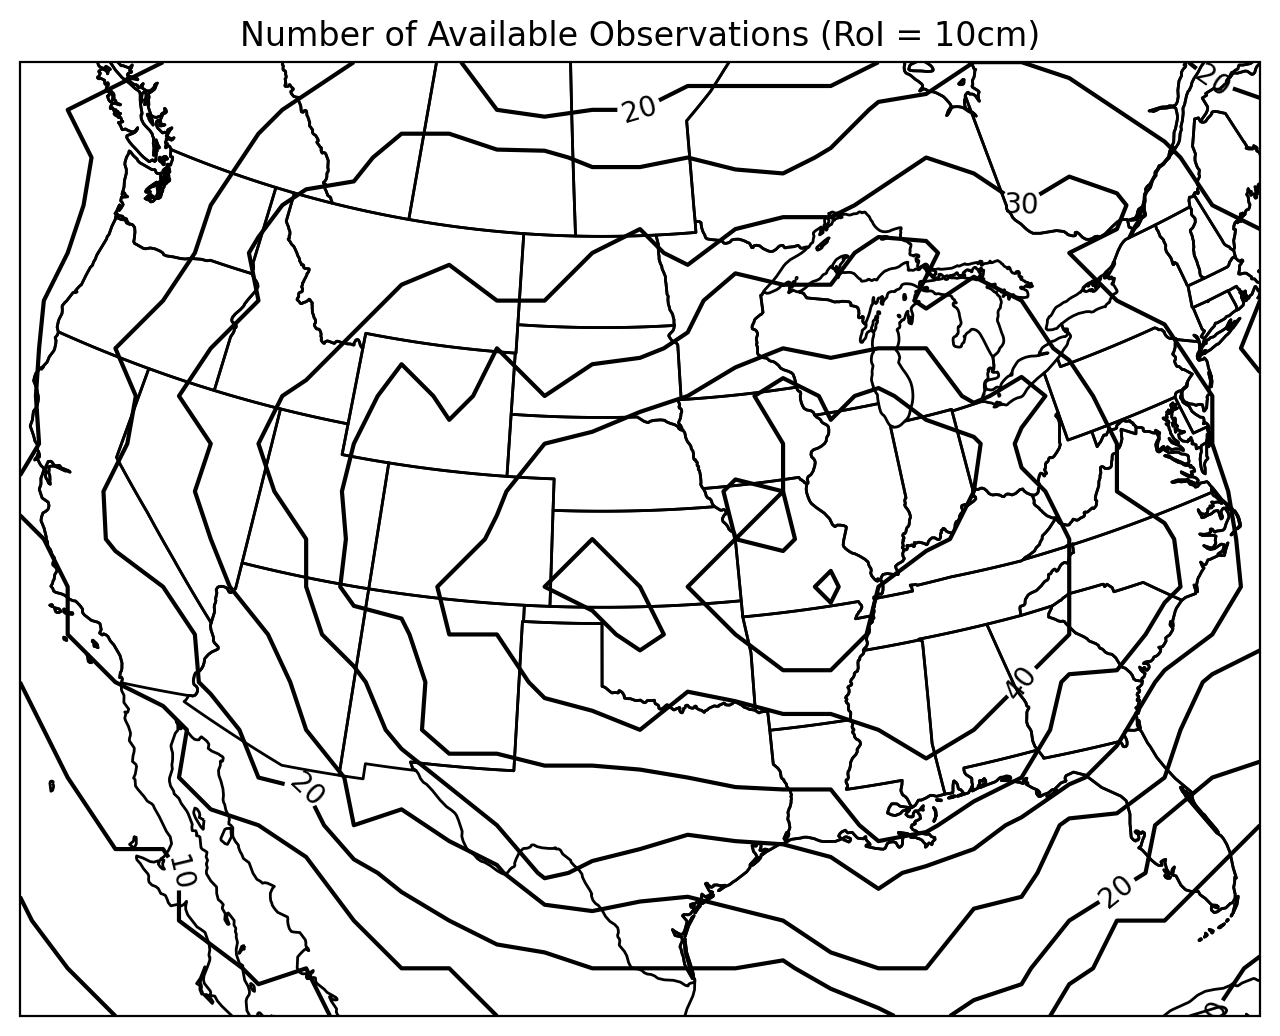

In [10]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,counts_10cm,colors='k',levels=np.arange(0,200,5),transform=proj)
plt.clabel(cs1,levels=np.arange(0,200,10))
ax1.set_title('Number of Available Observations (RoI = 10cm)')
plt.savefig('obs_counts_10cm.png', dpi = 300, bbox_inches = 'tight')

plt.show()

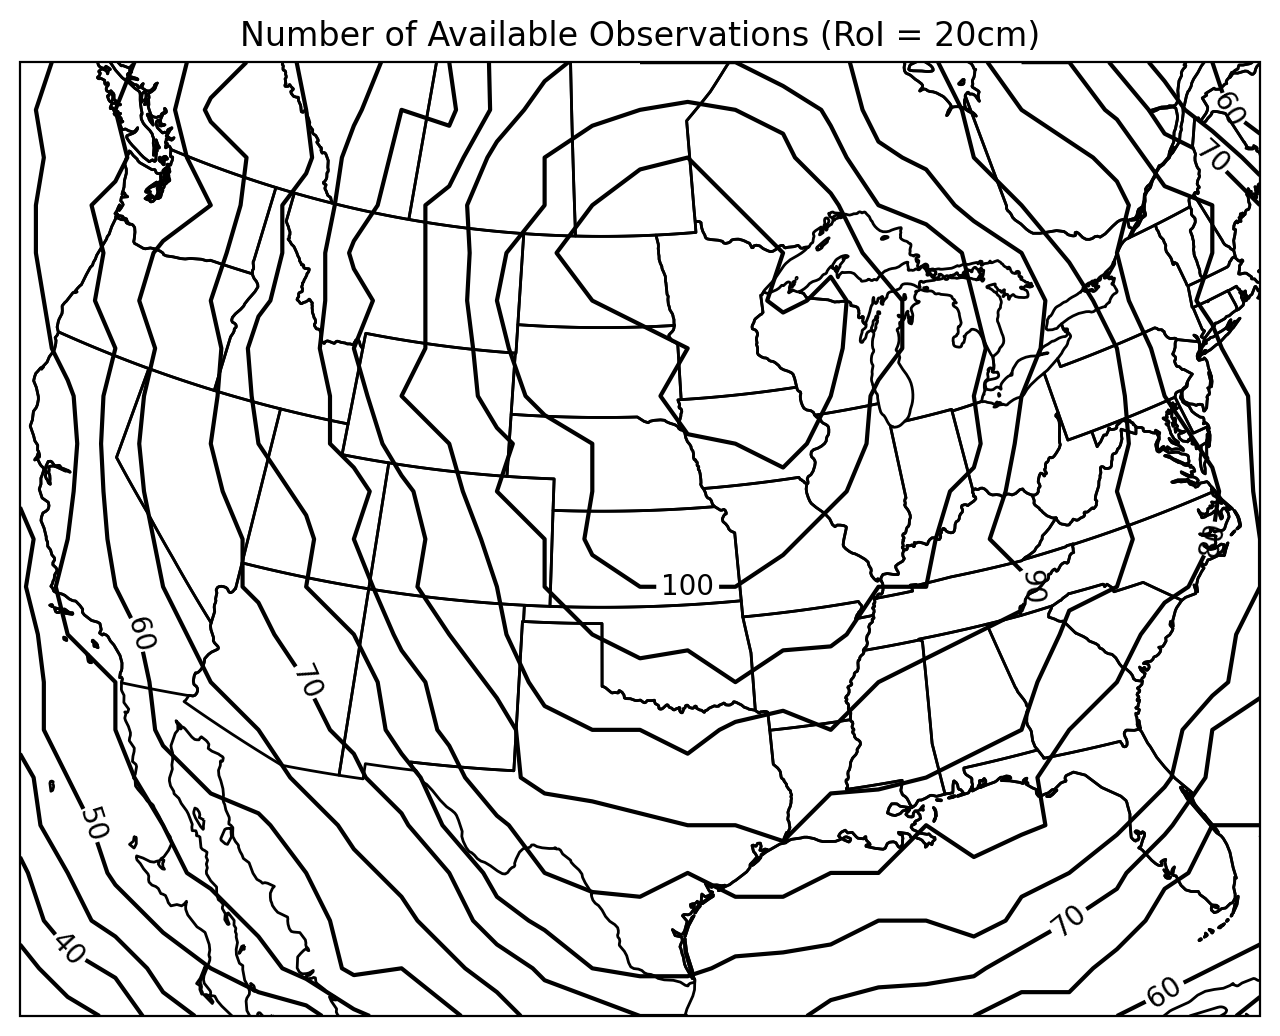

In [11]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,counts_20cm,colors='k',levels=np.arange(0,200,5),transform=proj)
plt.clabel(cs1,levels=np.arange(0,200,10))
ax1.set_title('Number of Available Observations (RoI = 20cm)')
plt.savefig('obs_counts_20cm.png', dpi = 300, bbox_inches = 'tight')

plt.show()

In [12]:
### Store the analyses in text files ###

np.savetxt('analysis_10cm.txt', analysis_10cm, fmt = '%.2f', header = '500mb Hgt Analysis (RoI = 10cm)')
np.savetxt('analysis_20cm.txt', analysis_20cm, fmt = '%.2f', header = '500mb Hgt Analysis (RoI = 20cm)')

In [13]:
### Store the number of observations available for each grid point in text files ###

np.savetxt('counts_10cm.txt', counts_10cm, fmt = '%d', header = 'Number of Available Observations (RoI = 10cm)')
np.savetxt('counts_20cm.txt', counts_20cm, fmt = '%d', header = 'Number of Available Observations (RoI = 20cm)')

In [ ]:
### In a separte text file (or below), answer the following questions ###
'''
1 - Describe the general features that you see in your contoured analyses.
    
    Geopotential Height Analysis:
    
    On both the 10cm and 20cm analysis for geopotential heights, there is a large scale trough over the western United States. The low associated with it
    is at the 4 corner states on the 10cm analysis. On the 20cm analysis, the trough is over the same area, but it is less pronounced in the sense of how
    far it dips into the south. This is particularly with regards to height values on the contours. Both geopotential height analysies show ridging over
    the eastern US. On the 10cm analysis, the ridge is associated with high pressure over the Gulf of Mexico. The 20cm analysis shows a more smooth
    ridge. This ridge is not as strong as in the 20cm analysis as it is in the 10cm analysis.

    Number of Available Obs Analysis:

    The number of available observations to resolve the plot is much less on the 10cm plot than the 20cm plot. There are random contours going through 
    other contours in Missouri. This shows that some data points on the 10cm analysis cannot resolve properly giving an odd shape. The 10cm plot still
    shows the majority of data points over the eastern part of the country. The contour showing the highest density of points is shifted to the south in
    the east central part of the country on 10cm radius of influence. The 20cm radius of influence shows the highest density shifted north into the 
    Wisconsin and Minnesota. This just means more points are in the radius of influence here than in other locations. The 20cm plot is smoother in this
    case as well. 

2 - Describe the differences that you see in your contoured analyses.  
    Does one analysis seem to be smoother than the other?  If so, what would cause this?

    Geopotential Height:
    
    The smoothness of the 20cm analysis is better and it includes more datapoints. The 10cm analysis has some issues with geopotential height contours 
    just to the west of Mexico. Those points do not include enough points in the radius of influence to resolve properly. The 20cm analysis solves this 
    problem and shows geopotential height properly to the west of Mexico. The cause of this smoother analysis is due to more points in the 20cm radius of
    influence as compared to the fewer analysis points in the 10cm radius of influence.

    Number of Available Obs:

    The same happens here with the 20cm roi being smoother due to more points availble per analysis. The 10cm plot shows a higher density available 
    in the missouri area while the 20cm shows more points available over Minnesota. This shows the radius of influence is important in being able to 
    get a good analysis. There needs to be a happy medium for this though as the radius of influence cannot be to big. If it is to big, the points go 
    off to infinity quickly; especially with higher degreed polynomials.

3 - Run your program using a radius of influence of 6 cm (do not need to show).  
    Describe the results - do they look realistic?  If there are problems, what
    do you think might be causing them?

    The geopotential height map looks realistic only in the areas with enough data to resolve the plot. In most spots, the plot is not realistic because
    the radius of influence for each point may not include 6 points minimum. In this case it shows. The number of available observations shows overlap 
    of contours which is not possible. This makes it clear that this radius of influence does not work.

4 - Suppose you ran this program with a small enough radius of influence that only one
    observation was available for determining a polynomial fit at a grid point.  Should
    you be able to perform the matrix inversion?  Why or why not?

    No, because there would not be enough points to resolve the equation. In the polynomial used in this code, there are six unknown coefficients that
    require six points to resolve. The matrix with one point would give a 1x6 instead of the minimum 6x6 matrix needed. Overall, the matrix inversion
    needed will fail in this case.

'''

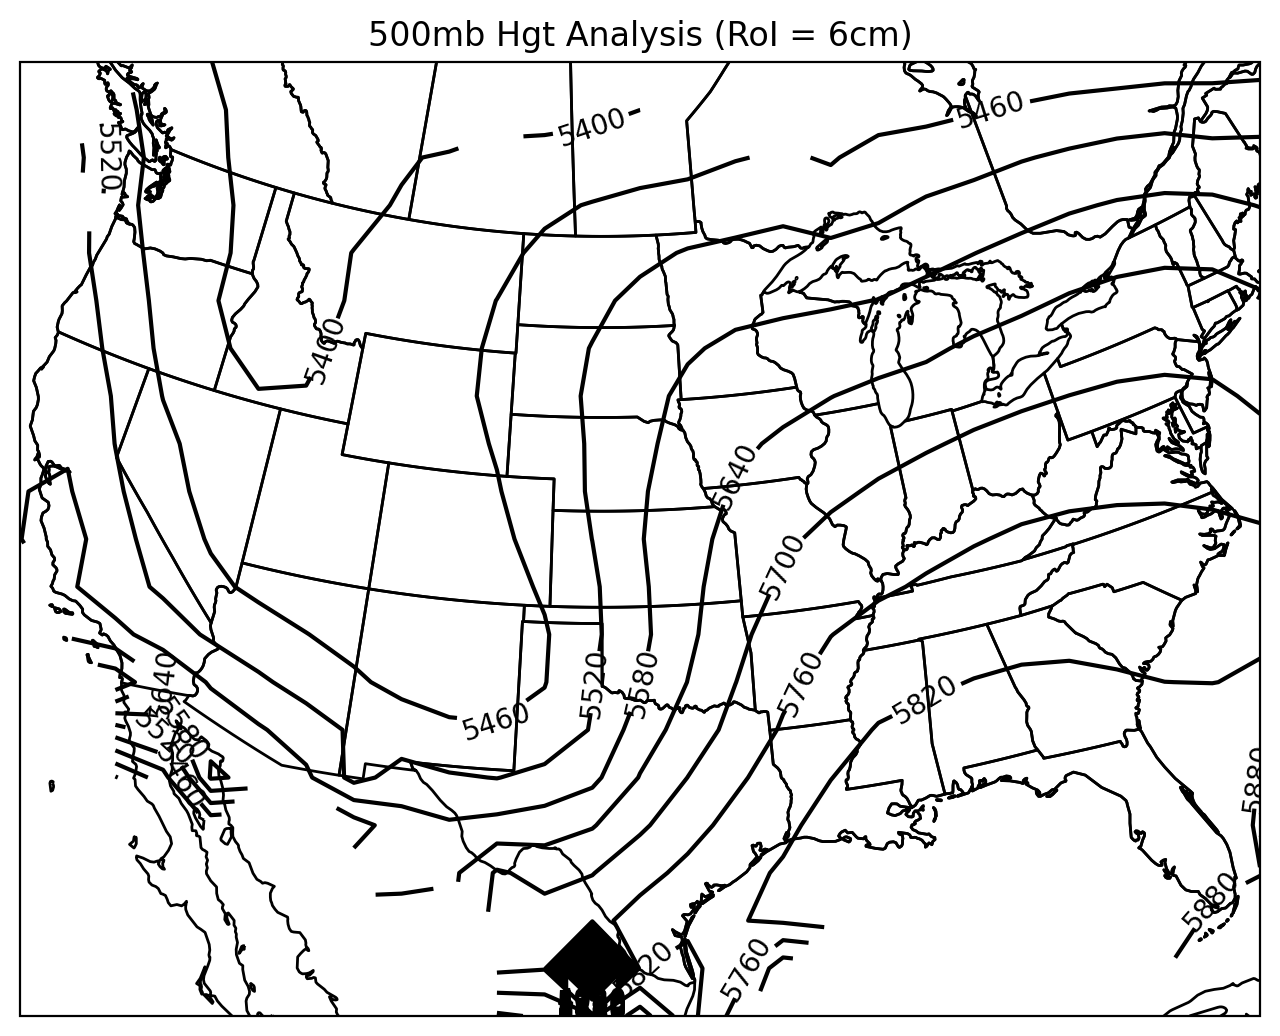

In [12]:
### Plot 500mb analyses over a map (20cm analysis) ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)

ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot analysis (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,analysis_6cm,colors='k',levels=np.arange(0,8000,60),transform=proj)
plt.clabel(cs1,levels=np.arange(0,8000,60))
ax1.set_title('500mb Hgt Analysis (RoI = 6cm)')


plt.show()

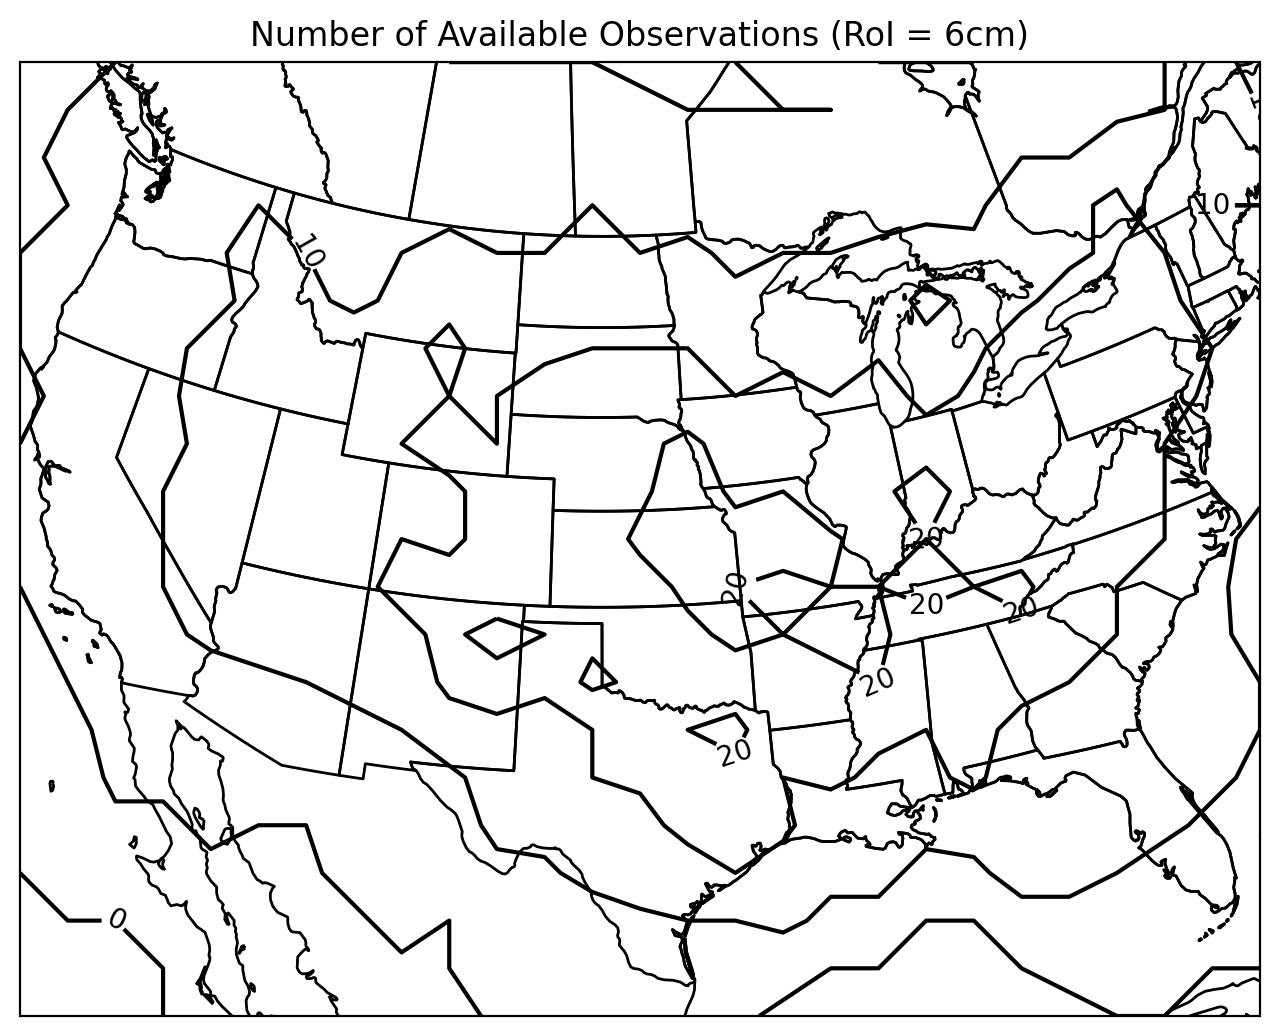

In [13]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,counts_6cm,colors='k',levels=np.arange(0,200,5),transform=proj)
plt.clabel(cs1,levels=np.arange(0,200,10))
ax1.set_title('Number of Available Observations (RoI = 6cm)')

plt.show()